In [2]:
# pip install nilearn

# 1. Load Atlas

In [3]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Since our objective is:

- Hippocampus
- Amygdala
- Entorhinal Cortex

the best choice is actually Juelich probabilistic atlas.

In [4]:
atlas_path = (
    "/home/enooo/fsl/data/atlases/Juelich/"
    "Juelich-maxprob-thr50-1mm.nii.gz"
)

atlas = nib.load(atlas_path)
atlas_data = atlas.get_fdata()

print(np.unique(atlas_data))
print(atlas_data.shape)

[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  25.  26.  27.  28.  29.
  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.  43.
  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.  57.
  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.  71.
  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.  85.
  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.  99.
 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113.
 114. 115. 116. 118. 120. 121.]
(182, 218, 182)


# 2. Define ROI labels

- For ROI extent analysis, we combine all of the target ROI labels into one binary mask.

In [5]:
roi_labels = [
    # Amygdala
    6, 7, 8, 9, 10, 11,

    # Hippocampus
    16, 17, 20, 21, 25,

    # Entorhinal cortex
    18, 19
]

**Note for users:** verify these label-name mappings against `Juelich.xml` for your installed FSL version before finalizing — atlas label numbering can change between FSL releases. Run:
```bash
grep -i "hippocamp\|amygdala\|entorhinal" /home/enooo/fsl/data/atlases/Juelich.xml
```
and cross-check the printed index attributes against the list above.

# Build combined ROI mask

For every voxel:

ROI(x,y,z) = 1 if the voxel belongs to one of the target structures, else 0.

Result: `roi_mask.shape = (182,218,182)` — a 3D binary mask of AD-relevant anatomy.

In [6]:
roi_mask = np.isin(atlas_data, roi_labels)

print("ROI voxels:", roi_mask.sum())
print("White voxels (True):", np.count_nonzero(roi_mask))
print("Black voxels (False):", roi_mask.size - np.count_nonzero(roi_mask))
print(f"Total voxels: {roi_mask.size}")  

ROI voxels: 31539
White voxels (True): 31539
Black voxels (False): 7189493
Total voxels: 7221032


In [7]:
import xml.etree.ElementTree as ET

tree = ET.parse('/home/enooo/fsl/data/atlases/Juelich.xml')
root = tree.getroot()

for label in root.iter('label'):
    idx = label.get('index')
    name = label.text
    if idx in ['16', '17', '20', '21', '25', '6','7','8','9','10','11','18','19']:
        print(f"Label {idx}: {name}")

Label 6: GM Amygdala_centromedial group L
Label 7: GM Amygdala_centromedial group R
Label 8: GM Amygdala_laterobasal group L
Label 9: GM Amygdala_laterobasal group R
Label 10: GM Amygdala_superficial group L
Label 11: GM Amygdala_superficial group R
Label 16: GM Hippocampus cornu ammonis L
Label 17: GM Hippocampus cornu ammonis R
Label 18: GM Hippocampus entorhinal cortex L
Label 19: GM Hippocampus entorhinal cortex R
Label 20: GM Hippocampus dentate gyrus L
Label 21: GM Hippocampus dentate gyrus R
Label 25: GM Hippocampus subiculum R


/tmp/ipykernel_31368/282881709.py:43: UserWarning: kwargs['alpha']=0.8 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(hip_img, cmap=blue_cmap, alpha=0.8)
/tmp/ipykernel_31368/282881709.py:44: UserWarning: kwargs['alpha']=0.8 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(amy_img, cmap=red_cmap, alpha=0.8)
/tmp/ipykernel_31368/282881709.py:45: UserWarning: kwargs['alpha']=0.8 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(ent_img, cmap=green_cmap, alpha=0.8)


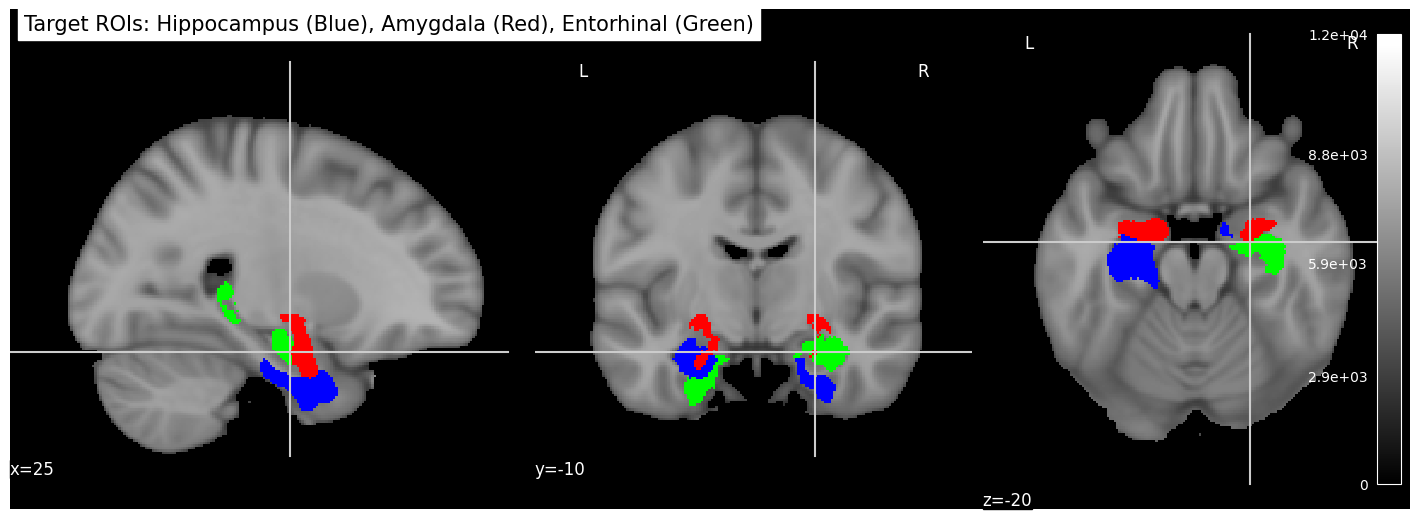

In [8]:
import nibabel as nib
import numpy as np
from nilearn import plotting
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ---------- 1. Load data ----------
mni_t1_path = "/home/enooo/fsl/data/standard/MNI152_T1_1mm_brain.nii.gz"
label_atlas_path = "/home/enooo/fsl/data/atlases/Juelich/Juelich-maxprob-thr50-1mm.nii.gz"

t1_img = nib.load(mni_t1_path)
label_img = nib.load(label_atlas_path)
label_data = label_img.get_fdata()

# ---------- 2. Build ROI masks ----------
amygdala_labels    = [6, 7, 8, 9, 10, 11]
hippocampus_labels = [16, 17, 20, 21, 25]
entorhinal_labels  = [18, 19]

def make_roi_img(label_data, labels, affine):
    mask = np.isin(label_data, labels).astype(np.int16)
    return nib.Nifti1Image(mask, affine)

amy_img = make_roi_img(label_data, amygdala_labels, label_img.affine)
hip_img = make_roi_img(label_data, hippocampus_labels, label_img.affine)
ent_img = make_roi_img(label_data, entorhinal_labels, label_img.affine)

# ---------- 3. Define SOLID single-color colormaps ----------
red_cmap   = ListedColormap(['red'])
blue_cmap  = ListedColormap(['blue'])
green_cmap = ListedColormap(['lime'])

# ---------- 4. Plot ----------
display = plotting.plot_anat(
    t1_img,
    display_mode='ortho',
    cut_coords=(25, -10, -20),
    title='Target ROIs: Hippocampus (Blue), Amygdala (Red), Entorhinal (Green)',
    figure=plt.figure(figsize=(14, 5)),
    black_bg=True
)

display.add_overlay(hip_img, cmap=blue_cmap, alpha=0.8)
display.add_overlay(amy_img, cmap=red_cmap, alpha=0.8)
display.add_overlay(ent_img, cmap=green_cmap, alpha=0.8)

plt.savefig(
    '/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/roi_overlay_ortho_colored.png',
    dpi=200, bbox_inches='tight', facecolor='black'
)
plt.show()

In [9]:
hippocampus_labels = [16, 17, 20, 21, 25]
mask_hip_full = np.isin(label_data, hippocampus_labels)

coords_full = np.array(np.where(mask_hip_full)).T
print("Z range (axial) of true hippocampus voxels:", coords_full[:,2].min(), "-", coords_full[:,2].max())
print("Y range (coronal):", coords_full[:,1].min(), "-", coords_full[:,1].max())
print("X range (sagittal):", coords_full[:,0].min(), "-", coords_full[:,0].max())

Z range (axial) of true hippocampus voxels: 27 - 109
Y range (coronal): 83 - 165
X range (sagittal): 27 - 128


# Quality check

In [10]:
print(atlas_data.shape)
print(np.unique(atlas_data)[:50])
print(np.unique(atlas_data).max())
print(roi_labels)
for label in roi_labels:
    print(label, np.sum(atlas_data == label))

print("Total ROI voxels (sum of per-label):",
      sum(np.sum(atlas_data == label) for label in roi_labels))

(182, 218, 182)
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 37.
 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51.]
121.0
[6, 7, 8, 9, 10, 11, 16, 17, 20, 21, 25, 18, 19]
6 187
7 257
8 303
9 1878
10 2056
11 1084
16 5153
17 4566
20 3994
21 545
25 3172
18 4807
19 3537
Total ROI voxels (sum of per-label): 31539


### Center-slice QC

To identify potentially misregistered volumes, a brain-center quality-control metric was computed. For each MRI volume, the first and last non-zero axial slices were identified, and the brain center was estimated as the midpoint between these boundaries. Subjects with center locations lying outside three standard deviations of the population mean were flagged as potential registration outliers and manually reviewed.

Subjects: 1626
Mean center: 89.71955719557195
Std center : 1.0638063436385248
Min center : 81.0
Max center : 94.5


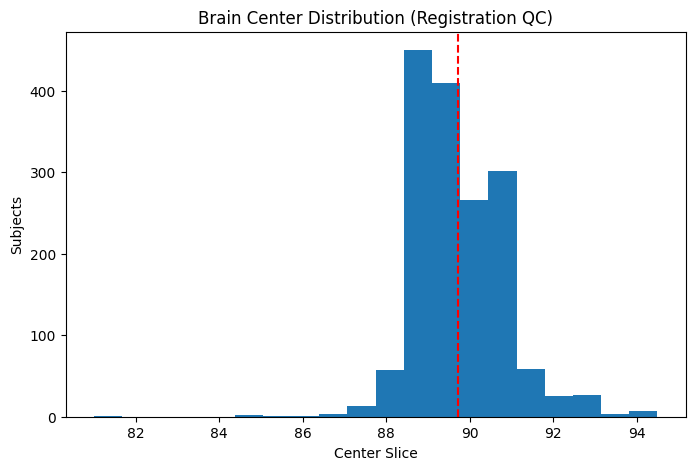

Limits: 86.52813816465638 92.91097622648752
Outliers: 24
041_S_4989_I453212.nii.gz: 94.0
023_S_4035_I533847.nii.gz: 93.5
041_S_4989_I396060.nii.gz: 94.5
035_S_4582_I337005.nii.gz: 93.0
082_S_4244_I399263.nii.gz: 86.5
127_S_0844_I54594.nii.gz: 81.0
037_S_4879_I388726.nii.gz: 94.5
128_S_4553_I344017.nii.gz: 86.0
068_S_2194_I242129.nii.gz: 94.5
072_S_2093_I489768.nii.gz: 93.0
073_S_4259_I397164.nii.gz: 85.0
073_S_4259_I305665.nii.gz: 85.0
068_S_2194_I205381.nii.gz: 94.0
014_S_4401_I414363.nii.gz: 93.5
033_S_1016_I56327.nii.gz: 93.0
073_S_4559_I339867.nii.gz: 94.0
037_S_0454_I501661.nii.gz: 93.0
072_S_4103_I325285.nii.gz: 86.5
014_S_4093_I314576.nii.gz: 93.5
033_S_1016_I160662.nii.gz: 93.0
073_S_4559_I313695.nii.gz: 93.0
032_S_4386_I621331.nii.gz: 94.0
013_S_1276_I141082.nii.gz: 85.5
033_S_1016_I29604.nii.gz: 93.0


In [ ]:
from pathlib import Path

root = "/home/enooo/Documents/Master/Early_Detection_AD/01_data/processed/classes/affine"
files = list(Path(root).rglob("*.nii.gz"))

results = []
for file in files:
    data = nib.load(file).get_fdata()
    profile = data.sum(axis=(1, 2))  # axial profile
    nonzero = np.where(profile > 0)[0]
    if len(nonzero) == 0:
        continue
    center = (nonzero.min() + nonzero.max()) / 2
    results.append((file.name, center))

centers = np.array([c for _, c in results])

print("Subjects:", len(centers))
print("Mean center:", centers.mean())
print("Std center :", centers.std())
print("Min center :", centers.min())
print("Max center :", centers.max())

plt.figure(figsize=(8, 5))
plt.hist(centers, bins=20)
plt.axvline(centers.mean(), linestyle="--", color='red')
plt.xlabel("Center Slice")
plt.ylabel("Subjects")
plt.title("Brain Center Distribution (Registration QC)")
plt.show()

lower = centers.mean() - 3 * centers.std()
upper = centers.mean() + 3 * centers.std()
print("Limits:", lower, upper)

outliers = [(name, center) for name, center in results if center < lower or center > upper]
print("Outliers:", len(outliers))
for name, center in outliers:
    print(f"{name}: {center:.1f}")

# 3. specifying brain tissue extent and ROI extent per plane:

## 1. brain tissue per plane

brain tissue (frontal cortex, occipital cortex, etc.) outside the ROI zone but still inside the skull — and zero-padding background outside that. We should detect true tissue extent the same way we detected ROI extent,

In [12]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd

# --------------------------------------------------
# Load one representative MRI
# --------------------------------------------------

root = Path(
    "/home/enooo/Documents/Master/Early_Detection_AD/01_data/processed/classes"
)

sample_path = next(
    root.rglob("*.nii.gz")
)

print("Sample:", sample_path)

img = nib.load(sample_path)
data = img.get_fdata()

print("Shape:", data.shape)

# --------------------------------------------------
# Tissue mask
# --------------------------------------------------

tissue_mask = data > 0

print("Tissue voxels:", tissue_mask.sum())
print(
    "Background voxels:",
    tissue_mask.size - tissue_mask.sum()
)

# --------------------------------------------------
# Axial
# --------------------------------------------------

axial_profile = tissue_mask.sum(axis=(0,1))

axial_slices = np.where(
    axial_profile > 0
)[0]

ax_tissue_first = axial_slices.min()
ax_tissue_last  = axial_slices.max()

ax_tissue_center = (
    ax_tissue_first + ax_tissue_last
) / 2

ax_tissue_width = (
    ax_tissue_last - ax_tissue_first + 1
)

# --------------------------------------------------
# Coronal
# --------------------------------------------------

cor_profile = tissue_mask.sum(axis=(0,2))

cor_slices = np.where(
    cor_profile > 0
)[0]

cor_tissue_first = cor_slices.min()
cor_tissue_last  = cor_slices.max()

cor_tissue_center = (
    cor_tissue_first + cor_tissue_last
) / 2

cor_tissue_width = (
    cor_tissue_last - cor_tissue_first + 1
)

# --------------------------------------------------
# Sagittal
# --------------------------------------------------

sag_profile = tissue_mask.sum(axis=(1,2))

sag_slices = np.where(
    sag_profile > 0
)[0]

sag_tissue_first = sag_slices.min()
sag_tissue_last  = sag_slices.max()

sag_tissue_center = (
    sag_tissue_first + sag_tissue_last
) / 2

sag_tissue_width = (
    sag_tissue_last - sag_tissue_first + 1
)

# --------------------------------------------------
# Summary table
# --------------------------------------------------

tissue_summary = pd.DataFrame({

    "Plane": [
        "Axial",
        "Coronal",
        "Sagittal"
    ],

    "First Slice": [
        ax_tissue_first,
        cor_tissue_first,
        sag_tissue_first
    ],

    "Last Slice": [
        ax_tissue_last,
        cor_tissue_last,
        sag_tissue_last
    ],

    "Center": [
        round(ax_tissue_center,1),
        round(cor_tissue_center,1),
        round(sag_tissue_center,1)
    ],

    "Tissue Width": [
        ax_tissue_width,
        cor_tissue_width,
        sag_tissue_width
    ],

    "Total Slices": [
        data.shape[2],
        data.shape[1],
        data.shape[0]
    ]
})

tissue_summary["% of Volume"] = (
    tissue_summary["Tissue Width"]
    /
    tissue_summary["Total Slices"]
    * 100
).round(1)

tissue_summary

Sample: /home/enooo/Documents/Master/Early_Detection_AD/01_data/processed/classes/MCI/037_S_0552_I84216.nii.gz
Shape: (182, 218, 182)
Tissue voxels: 1207151
Background voxels: 6013881


,Plane,First Slice,Last Slice,Center,Tissue Width,Total Slices,% of Volume
0,Axial,20,153,86.5,134,182,73.6
1,Coronal,25,178,101.5,154,218,70.6
2,Sagittal,22,155,88.5,134,182,73.6


## 2. ROI coverage per plane

ROI-rich zone: `ax_first → ax_last` shows how much ROI exists inside each slice (voxel count), not image intensity.

In [13]:
axial_presence = roi_mask.sum(axis=(0, 1))
axial_slices = np.where(axial_presence > 0)[0]

ax_first = axial_slices.min()
ax_last  = axial_slices.max()
ax_center = (ax_first + ax_last) / 2
ax_width  = (ax_last - ax_first + 1)

print(ax_first, ax_last, ax_center, ax_width)

26 129 77.5 104


In [14]:
cor_presence = roi_mask.sum(axis=(0, 2))
cor_slices = np.where(cor_presence > 0)[0]

cor_first = cor_slices.min()
cor_last  = cor_slices.max()
cor_center = (cor_first + cor_last) / 2
cor_width  = (cor_last - cor_first + 1)

print(cor_first, cor_last, cor_center, cor_width)

66 165 115.5 100


In [15]:
sag_presence = roi_mask.sum(axis=(1, 2))
sag_slices = np.where(sag_presence > 0)[0]

sag_first = sag_slices.min()
sag_last  = sag_slices.max()
sag_center = (sag_first + sag_last) / 2
sag_width  = (sag_last - sag_first + 1)

print(sag_first, sag_last, sag_center, sag_width)

27 128 77.5 102


### Plane extent summary table

Consolidates all three planes for comparison.

In [16]:
plane_summary = pd.DataFrame({
    'Plane'      : ['Axial', 'Coronal', 'Sagittal'],
    'First Slice': [ax_first, cor_first, sag_first],
    'Last Slice' : [ax_last,  cor_last,  sag_last],
    'Center'     : [ax_center, cor_center, sag_center],
    'ROI Width'  : [ax_width, cor_width, sag_width],
    'Total Slices': [182, 218, 182],
})
plane_summary['% of Volume'] = (
    plane_summary['ROI Width'] / plane_summary['Total Slices'] * 100
).round(1)

plane_summary

,Plane,First Slice,Last Slice,Center,ROI Width,Total Slices,% of Volume
0,Axial,26,129,77.5,104,182,57.1
1,Coronal,66,165,115.5,100,218,45.9
2,Sagittal,27,128,77.5,102,182,56.0


# 4. Plot ROI extent

ROI-rich zone (axial): `ax_first → ax_last` inside `0 → 181` (whole brain).

Therefore: `ROI width / 182` = the fraction of axial slices containing at least part of the target ROI.

From the plot below: the hippocampus/amygdala/entorhinal cortex are concentrated near the middle slices — evidence that center slices are richer than boundary slices, supporting a hybrid sampling strategy.

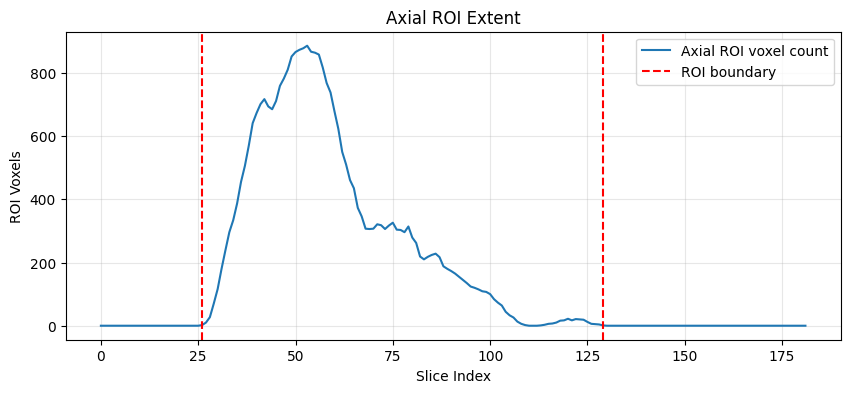

ROI-rich zone: 26 -> 129  (104/182 = 57.1% of axial slices)


In [17]:
plt.figure(figsize=(10, 4))
plt.plot(axial_presence, label="Axial ROI voxel count")
plt.axvline(ax_first, linestyle='--', color='red', label='ROI boundary')
plt.axvline(ax_last, linestyle='--', color='red')
plt.title("Axial ROI Extent")
plt.xlabel("Slice Index")
plt.ylabel("ROI Voxels")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

roi_pct = ax_width / 182 * 100
print(f"ROI-rich zone: {ax_first} -> {ax_last}  ({ax_width}/182 = {roi_pct:.1f}% of axial slices)")

# 5. Global Coverage Analysis (Uniform selection)

### Experiment 1 (Slice-count coverage vs k)

Uses `linspace` to generate k evenly spaced positions across the **full 182-slice volume**, then asks: of the slices that intersect the ROI zone, how many are captured?

P = (selected slices ∩ ROI-zone slices) / (total ROI-zone slices)

where a slice is "in the ROI zone" if its index falls between `ax_first` and `ax_last` — this is a coarse, slice-counting metric (not voxel-weighted).

In [18]:
def select_uniform(n_slices, k):
    return np.round(np.linspace(0, n_slices - 1, k)).astype(int)

def roi_coverage_voxel(selected, roi_per_slice):
    """
    Voxel-based ROI coverage: fraction of total ROI voxels
    captured by the selected slices.
    Consistent with Experiment 2's metric.
    """
    covered = roi_per_slice[selected].sum()
    total   = roi_per_slice.sum()
    return covered / total


### Unified K range



In [19]:
K_VALUES = [4, 8, 12, 16, 20, 24, 32, 40, 48, 64, 80, 96, 104, 128, 150, 182]

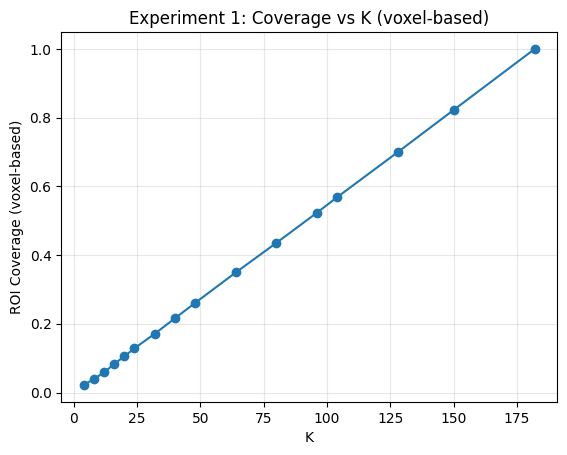

In [20]:
coverage = []
roi_per_slice = roi_mask.sum(axis=(0, 1))

for k in K_VALUES:
    selected = select_uniform(182, k)           # uniform across full 182 slices
    cov = roi_coverage_voxel(selected, roi_per_slice)
    coverage.append(cov)

plt.plot(K_VALUES, coverage, marker='o')
plt.xlabel("K")
plt.ylabel("ROI Coverage (voxel-based)")        # label now matches Exp 2
plt.title("Experiment 1: Coverage vs K (voxel-based)")
plt.grid(alpha=0.3)
plt.show()


### Experiment 2 ( ROI Voxel-weighted coverage vs k)

Sample only within the ROI-rich zone (`ax_first → ax_last`).

P = (ROI voxels in selected slices) / (total ROI voxels)

This reflects how much **anatomical information** is retained, not just how many slice indices are touched.

Steps: uniformly select K slices within the ROI zone -> sum ROI voxels in those slices -> divide by total ROI voxels.

In [21]:
roi_per_slice = roi_mask.sum(axis=(0, 1))

print("Number of axial slices:", len(roi_per_slice))
print("Total ROI voxels:", roi_per_slice.sum())

Number of axial slices: 182
Total ROI voxels: 31539


In [22]:
def roi_sampling_coverage(k, roi_per_slice, first_slice, last_slice):
    roi_region = np.arange(first_slice, last_slice + 1)
    idx = np.unique(np.linspace(0, len(roi_region) - 1, k, dtype=int))  # dedupe
    selected_slices = roi_region[idx]
    covered = roi_per_slice[selected_slices].sum()
    return covered / roi_per_slice.sum()

In [23]:
roi_cov = []
for k in K_VALUES:
    roi_cov.append(
        roi_sampling_coverage(k, roi_per_slice, ax_first, ax_last)
    )

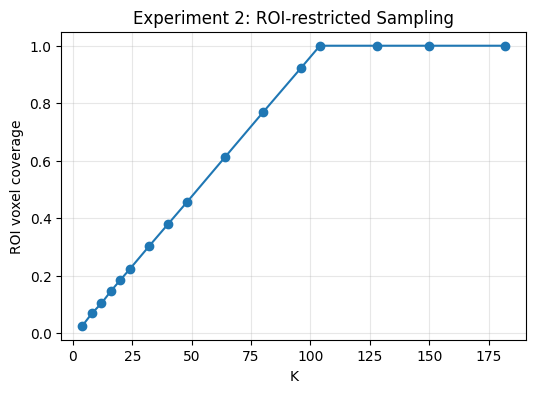

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(K_VALUES, roi_cov, marker="o")
plt.xlabel("K")
plt.ylabel("ROI voxel coverage")
plt.title("Experiment 2: ROI-restricted Sampling")
plt.grid(True, alpha=0.3)
plt.show()